# Project Python Foundations: FoodHub Data Analysis

### Context

The number of restaurants in New York is increasing day by day. Lots of students and busy professionals rely on those restaurants due to their hectic lifestyles. Online food delivery service is a great option for them. It provides them with good food from their favorite restaurants. A food aggregator company FoodHub offers access to multiple restaurants through a single smartphone app.

The app allows the restaurants to receive a direct online order from a customer. The app assigns a delivery person from the company to pick up the order after it is confirmed by the restaurant. The delivery person then uses the map to reach the restaurant and waits for the food package. Once the food package is handed over to the delivery person, he/she confirms the pick-up in the app and travels to the customer's location to deliver the food. The delivery person confirms the drop-off in the app after delivering the food package to the customer. The customer can rate the order in the app. The food aggregator earns money by collecting a fixed margin of the delivery order from the restaurants.

### Objective

The food aggregator company has stored the data of the different orders made by the registered customers in their online portal. They want to analyze the data to get a fair idea about the demand of different restaurants which will help them in enhancing their customer experience. Suppose you are hired as a Data Scientist in this company and the Data Science team has shared some of the key questions that need to be answered. Perform the data analysis to find answers to these questions that will help the company to improve the business.

### Data Description

The data contains the different data related to a food order. The detailed data dictionary is given below.

### Data Dictionary

* order_id: Unique ID of the order
* customer_id: ID of the customer who ordered the food
* restaurant_name: Name of the restaurant
* cuisine_type: Cuisine ordered by the customer
* cost_of_the_order: Cost of the order
* day_of_the_week: Indicates whether the order is placed on a weekday or weekend (The weekday is from Monday to Friday and the weekend is Saturday and Sunday)
* rating: Rating given by the customer out of 5
* food_preparation_time: Time (in minutes) taken by the restaurant to prepare the food. This is calculated by taking the difference between the timestamps of the restaurant's order confirmation and the delivery person's pick-up confirmation.
* delivery_time: Time (in minutes) taken by the delivery person to deliver the food package. This is calculated by taking the difference between the timestamps of the delivery person's pick-up confirmation and drop-off information

### Let us start by importing the required libraries

In [1]:
# Installing the libraries with the specified version.
!pip install numpy==1.25.2 pandas==2.0.3 matplotlib==3.7.1 seaborn==0.13.1 -q --user

**Note**: *After running the above cell, kindly restart the notebook kernel and run all cells sequentially from the start again.*

In [2]:
# import libraries for data manipulation
import numpy as np
import pandas as pd

# import libraries for data visualization
import matplotlib.pyplot as plt
import seaborn as sns

### Understanding the structure of the data

In [3]:
# uncomment and run the following lines for Google Colab
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
# Write your code here to read the data

# Loading the data from the source csv located in Google drive into a dataframe
data = pd.read_csv('/content/drive/MyDrive/PGP-AIML/Python Foundations/Project/foodhub_order.csv')

# Keeping a copy of the original data.
data_orig = data.copy()

In [5]:
# Write your code here to view the first 5 rows

# Fetching the first 5 rows of the data frame. Note that the index starts
data.head()

,order_id,customer_id,restaurant_name,cuisine_type,cost_of_the_order,day_of_the_week,rating,food_preparation_time,delivery_time
0,1477147,337525,Hangawi,Korean,30.75,Weekend,Not given,25,20
1,1477685,358141,Blue Ribbon Sushi Izakaya,Japanese,12.08,Weekend,Not given,25,23
2,1477070,66393,Cafe Habana,Mexican,12.23,Weekday,5,23,28
3,1477334,106968,Blue Ribbon Fried Chicken,American,29.20,Weekend,3,25,15
4,1478249,76942,Dirty Bird to Go,American,11.59,Weekday,4,25,24


### **Question 1:** How many rows and columns are present in the data? [0.5 mark]

In [6]:
# Checking the shape of the data i.e. total number of rows and columns of the given dataframe.

print('Number of rows: ', data.shape[0])
print('Number of columns: ', data.shape[1])

Number of rows:  1898
Number of columns:  9


#### Observations:
*   Total Number of rows:  1898
*   Total Number of columns:  9



### **Question 2:** What are the datatypes of the different columns in the dataset? (The info() function can be used) [0.5 mark]

In [7]:
# Checking the datatypes of the columns in the dataframe

data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1898 entries, 0 to 1897
Data columns (total 9 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   order_id               1898 non-null   int64  
 1   customer_id            1898 non-null   int64  
 2   restaurant_name        1898 non-null   object 
 3   cuisine_type           1898 non-null   object 
 4   cost_of_the_order      1898 non-null   float64
 5   day_of_the_week        1898 non-null   object 
 6   rating                 1898 non-null   object 
 7   food_preparation_time  1898 non-null   int64  
 8   delivery_time          1898 non-null   int64  
dtypes: float64(1), int64(4), object(4)
memory usage: 133.6+ KB


#### Observations:


*   There are a total of 9 columns in the dataframe, of those 5 are numerical columns and 4 are object type columns.
*   Rating column is read as object type instead of int64 or float64, that is probably because of invalid or missing data in that column. Further evaluation is needed.






### **Question 3:** Are there any missing values in the data? If yes, treat them using an appropriate method. [1 mark]

In [8]:
data.describe()

,order_id,customer_id,cost_of_the_order,food_preparation_time,delivery_time
count,1.898000e+03,1898.000000,1898.000000,1898.000000,1898.000000
mean,1.477496e+06,171168.478398,16.498851,27.371970,24.161749
std,5.480497e+02,113698.139743,7.483812,4.632481,4.972637
min,1.476547e+06,1311.000000,4.470000,20.000000,15.000000
25%,1.477021e+06,77787.750000,12.080000,23.000000,20.000000
50%,1.477496e+06,128600.000000,14.140000,27.000000,25.000000
75%,1.477970e+06,270525.000000,22.297500,31.000000,28.000000
max,1.478444e+06,405334.000000,35.410000,35.000000,33.000000


In [9]:
# describing the non-numerical columns in the data
data.describe(include='object')

,restaurant_name,cuisine_type,day_of_the_week,rating
count,1898,1898,1898,1898
unique,178,14,2,4
top,Shake Shack,American,Weekend,Not given
freq,219,584,1351,736


In [10]:
# checking for the null values in the data
data.isnull().sum()

order_id                 0
customer_id              0
restaurant_name          0
cuisine_type             0
cost_of_the_order        0
day_of_the_week          0
rating                   0
food_preparation_time    0
delivery_time            0
dtype: int64

In [11]:
# checking for all unique values in the rating column
data['rating'].unique()

array(['Not given', '5', '3', '4'], dtype=object)

In [12]:
# finding total number of rows with 'Not given' value for rating column
(data['rating'] == 'Not given').value_counts()

rating
False    1162
True      736
Name: count, dtype: int64

In [13]:
# check how is the data for other columns where the rating is 'Not given'. This is to check if those rows can be dropped or not. If other columns have valid data we cannot drop those rows.
data[data['rating'] == 'Not given']

,order_id,customer_id,restaurant_name,cuisine_type,cost_of_the_order,day_of_the_week,rating,food_preparation_time,delivery_time
0,1477147,337525,Hangawi,Korean,30.75,Weekend,Not given,25,20
1,1477685,358141,Blue Ribbon Sushi Izakaya,Japanese,12.08,Weekend,Not given,25,23
6,1477894,157711,The Meatball Shop,Italian,6.07,Weekend,Not given,28,21
10,1477895,143926,Big Wong Restaurant _¤¾Ñ¼,Chinese,5.92,Weekday,Not given,34,28
14,1478198,62667,Lucky's Famous Burgers,American,12.13,Weekday,Not given,23,30
...,...,...,...,...,...,...,...,...,...
1887,1476873,237616,Shake Shack,American,5.82,Weekend,Not given,26,30
1891,1476981,138586,Shake Shack,American,5.82,Weekend,Not given,22,28
1892,1477473,97838,Han Dynasty,Chinese,29.15,Weekend,Not given,29,21
1895,1477819,35309,Blue Ribbon Sushi,Japanese,25.22,Weekday,Not given,31,24


In [14]:
# Replacing the 'Not given' values in the rating
data['rating'] = data['rating'].replace(['Not given'],np.nan)

# changing the data type to float
data['rating'] = data['rating'].astype(float)

data.info()

data['rating'].unique()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1898 entries, 0 to 1897
Data columns (total 9 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   order_id               1898 non-null   int64  
 1   customer_id            1898 non-null   int64  
 2   restaurant_name        1898 non-null   object 
 3   cuisine_type           1898 non-null   object 
 4   cost_of_the_order      1898 non-null   float64
 5   day_of_the_week        1898 non-null   object 
 6   rating                 1162 non-null   float64
 7   food_preparation_time  1898 non-null   int64  
 8   delivery_time          1898 non-null   int64  
dtypes: float64(2), int64(4), object(3)
memory usage: 133.6+ KB


array([nan,  5.,  3.,  4.])

In [15]:
data.isnull().sum()

order_id                   0
customer_id                0
restaurant_name            0
cuisine_type               0
cost_of_the_order          0
day_of_the_week            0
rating                   736
food_preparation_time      0
delivery_time              0
dtype: int64

#### Observations:

1.   Other than rating column no other columns seem to have missing values.
2.   Rows with missing rating values cannot be dropped as other columns have valid date in them.
3.   Missing rating values cannot be imputed with mean or median or mode methods as those would make the date biased and skewed, so those methods are not appopriate for use in this case.
4.   Instead we could replace the 'Not given' values with NaN and then convert the column from Object type to Float type, which will help us later in further analysis.




### **Question 4:** Check the statistical summary of the data. What is the minimum, average, and maximum time it takes for food to be prepared once an order is placed? [2 marks]

In [16]:
data.describe()

,order_id,customer_id,cost_of_the_order,rating,food_preparation_time,delivery_time
count,1.898000e+03,1898.000000,1898.000000,1162.000000,1898.000000,1898.000000
mean,1.477496e+06,171168.478398,16.498851,4.344234,27.371970,24.161749
std,5.480497e+02,113698.139743,7.483812,0.741478,4.632481,4.972637
min,1.476547e+06,1311.000000,4.470000,3.000000,20.000000,15.000000
25%,1.477021e+06,77787.750000,12.080000,4.000000,23.000000,20.000000
50%,1.477496e+06,128600.000000,14.140000,5.000000,27.000000,25.000000
75%,1.477970e+06,270525.000000,22.297500,5.000000,31.000000,28.000000
max,1.478444e+06,405334.000000,35.410000,5.000000,35.000000,33.000000


#### Observations:

Time taken for food to be prepared ==> food_preparation_time
*   Minimum time taken for the food to be prepared = 20.00 mins
*   Average time taken for the food to be prepared = 27.37 mins
*   Maximum time taken for the food to be prepared = 35.00 mins






### **Question 5:** How many orders are not rated? [1 mark]

In [17]:
# Count total number of null values in rating column
data['rating'].isnull().sum()

736

#### Observations:


*   As we converted the 'Not given' values to nan in the rating column. Counting the total null values would give us the total number of orders which aren't rated, that is 736.





### Exploratory Data Analysis (EDA)

### Univariate Analysis

### **Question 6:** Explore all the variables and provide observations on their distributions. (Generally, histograms, boxplots, countplots, etc. are used for univariate exploration.) [9 marks]

**6.1. General Observations**





In [18]:
# Making a list of all categorical variables
cat_cols =  ['order_id', 'customer_id', 'restaurant_name', 'cuisine_type','day_of_the_week','rating']

for column in cat_cols:
    print('Number of unique values in', column ,'are:', data[column].nunique())
    print("-" * 60)

Number of unique values in order_id are: 1898
------------------------------------------------------------
Number of unique values in customer_id are: 1200
------------------------------------------------------------
Number of unique values in restaurant_name are: 178
------------------------------------------------------------
Number of unique values in cuisine_type are: 14
------------------------------------------------------------
Number of unique values in day_of_the_week are: 2
------------------------------------------------------------
Number of unique values in rating are: 3
------------------------------------------------------------


**6.2. Observations on Cuisine type**





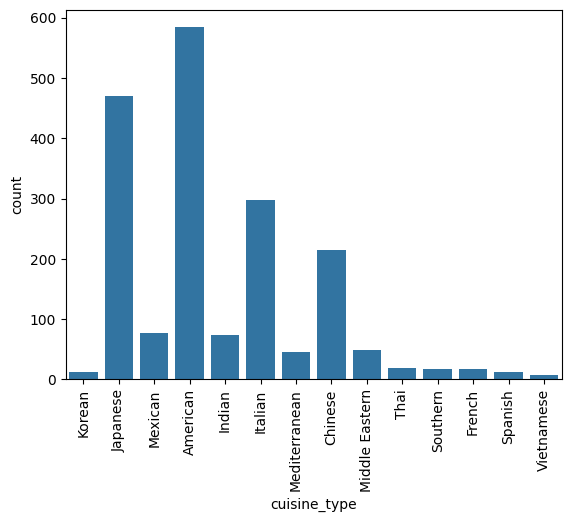

In [19]:
sns.countplot(data=data,x='cuisine_type')
plt.xticks(rotation=90)
plt.show()

*   American, Japanese, Italian and Chinese are the top 4 most ordered cuisines over all. In general they are ordered significantly more than the rest of the cuisines.


---



**6.3. Observations on orders placed on the day of the week**



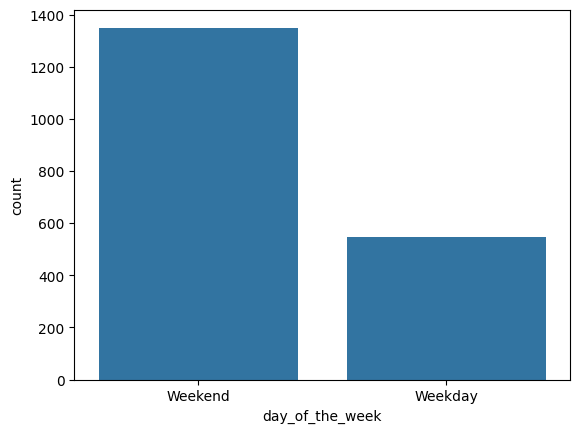

In [20]:
sns.countplot(data=data,x='day_of_the_week')
plt.show()

*   Significantly more orders have been placed on Weekends than weekdays.


---




**6.4. Observations on Cost of the orders**









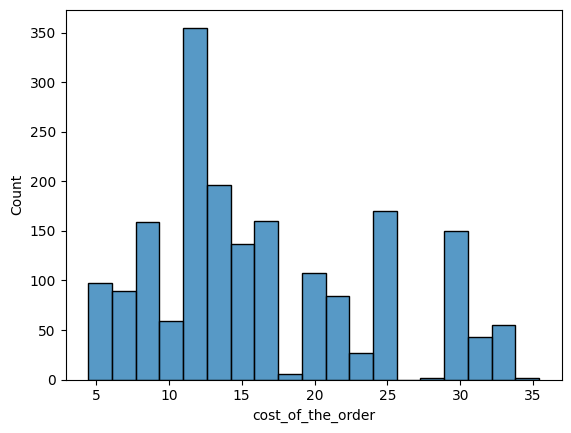

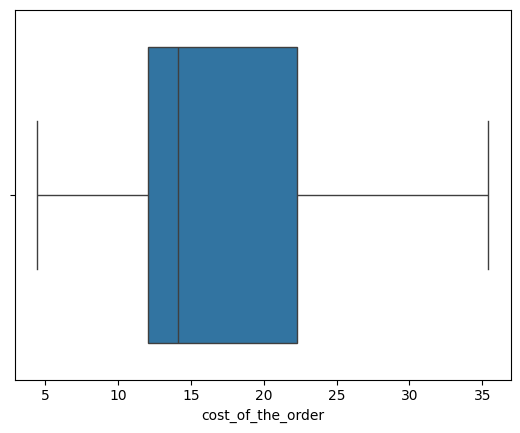

In [21]:
sns.histplot(data=data,x='cost_of_the_order')
plt.show()
sns.boxplot(data=data,x='cost_of_the_order')
plt.show()


*   The distribution is slightly right skewed

*   More than 75% of the orders were less than $25

*   Maximum price of the order seem to be about $35

*   Most of the orders were on average about $14

*   About 25% of the orders were less than $12


---



**6.6. Observations on Order Ratings**








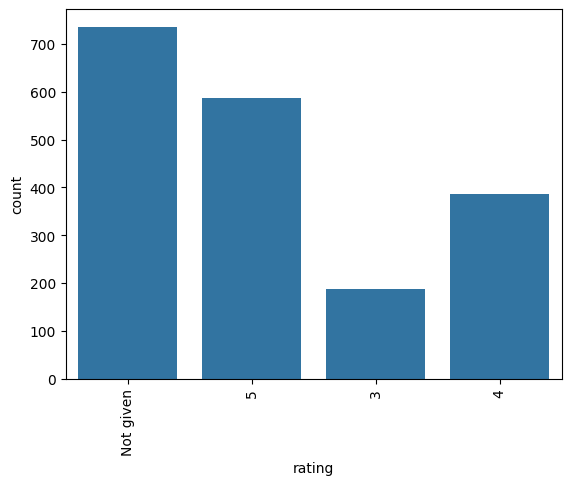

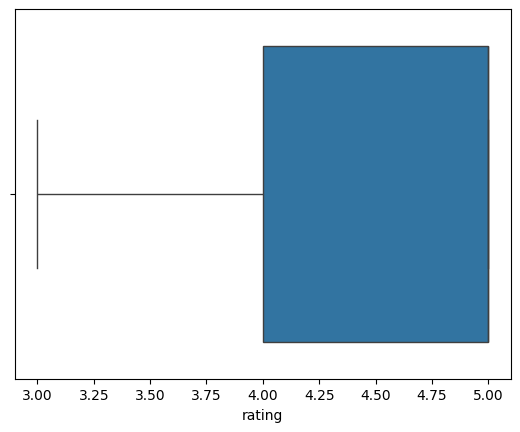

In [22]:
# The following analysis includes data where the ratings have not been given.
sns.countplot(data=data_orig,x='rating')
plt.xticks(rotation=90)
plt.show()

# The following analysis includes only the data where the ratings are available.
sns.boxplot(data=data,x='rating')
plt.show()

*   Majority of the orders have not been rated.
*   Out of the orders which have been rated -
    *   Most of them have been rated 5
    *   Over 75% of the orders were rated more than 4
    *   Least rating for the order seem to be 3


---



**6.5. Observations on Food Preparation Time**








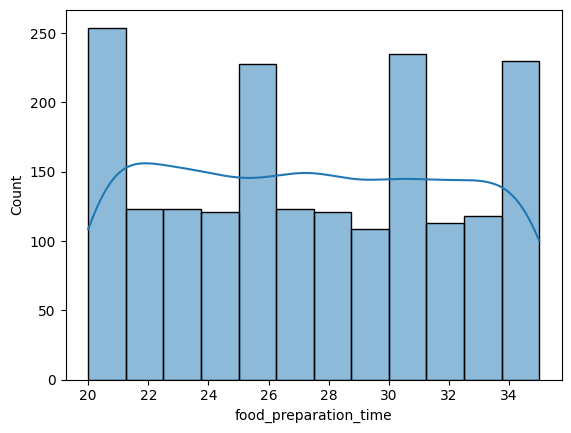

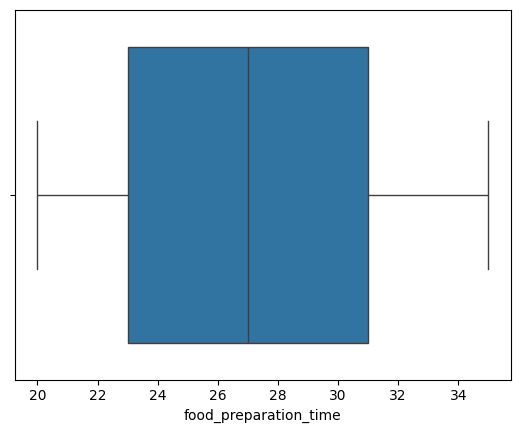

In [23]:
sns.histplot(data=data,x='food_preparation_time',kde=True)
plt.show()
sns.boxplot(data=data,x='food_preparation_time')
plt.show()

*   The distribution is symmetrical
*   Minimum time needed for food preparation is 20 mins
*   25% of the orders were prepared in less than 23 mins
*   50% of the orders were prepared in less than 27 mins
*   75% of the orders were prepared in less than 31 mins
*   100% of the orders were prepared in less than 35 mins
*   No outliers found in the distribution


---



**6.7. Observations on Delivery Time**








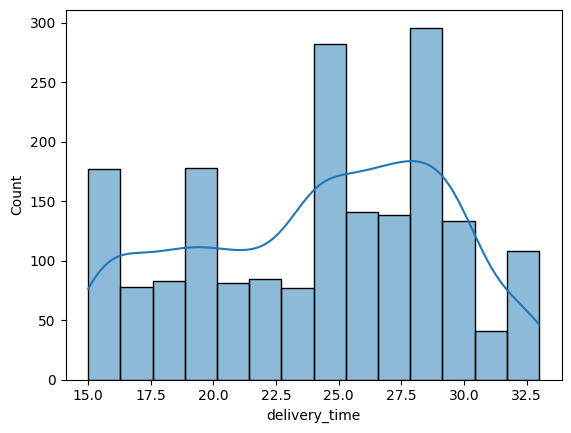

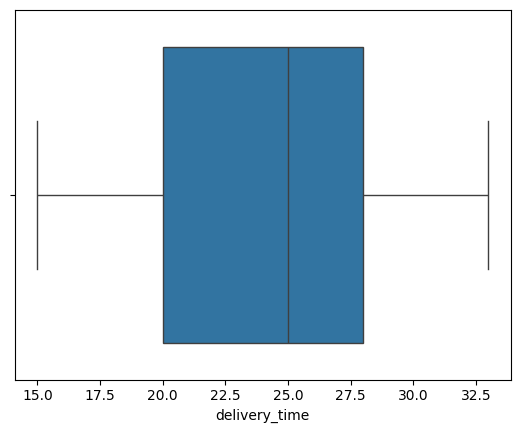

In [24]:
sns.histplot(data=data,x='delivery_time',kde=True)
plt.show()
sns.boxplot(data=data,x='delivery_time')
plt.show()


*   The distribution is slightly left skewed
*   Minimum time took for delivery is 15 mins.
*   25% of the orders were delivered less than 20 mins
*   50% of the orders were delivered in less than 25 mins
*   75% of the orders were delivered in less than 28 mins
*   100% of the orders were delivered in less than 34 mins
*   No outliers found in the distribution


---



### **Question 7**: Which are the top 5 restaurants in terms of the number of orders received? [1 mark]

In [25]:
# Top 5 restaurants interms of number of orders received.
data['restaurant_name'].value_counts().head()

restaurant_name
Shake Shack                  219
The Meatball Shop            132
Blue Ribbon Sushi            119
Blue Ribbon Fried Chicken     96
Parm                          68
Name: count, dtype: int64

#### Observations:
Following are the top 5 restaurants interms of the number of orders received in descending order:

*   Shake Shack
*   The Meatball Shop
*   Blue Ribbon Sushi
*   Blue Ribbon Fried Chicken
*   Parm









### **Question 8**: Which is the most popular cuisine on weekends? [1 mark]

In [26]:
# The most popular cuisine on weekends
data[data['day_of_the_week'] == 'Weekend']['cuisine_type'].value_counts().head(1)


cuisine_type
American    415
Name: count, dtype: int64

#### Observations:
The Most popular cuisine on the weekends is American.

### **Question 9**: What percentage of the orders cost more than 20 dollars? [2 marks]

In [27]:
# Percentage of orders that cost more than 20 dollars
(data[data['cost_of_the_order'] > 20].shape[0] / data.shape[0]) * 100

29.24130663856691

#### Observations:
29.24% of the total orders cost more than 20 dollars.

### **Question 10**: What is the mean order delivery time? [1 mark]

In [28]:
# Mean order delivery time
data['delivery_time'].mean()

24.161749209694417

#### Observations:
Mean of the Order delivery time is: 24.16 minutes.


### **Question 11:** The company has decided to give 20% discount vouchers to the top 3 most frequent customers. Find the IDs of these customers and the number of orders they placed. [1 mark]

In [29]:
# Customer ids of the top 3 most frequent customers and the total number of orders they placed
data['customer_id'].value_counts().head(3)

customer_id
52832    13
47440    10
83287     9
Name: count, dtype: int64

#### Observations:
Following are the customer ids and number of orders placed by top 3 most frequent customers:

*   52832 --> 13
*   47440 --> 10
*   83287 --> 9









### Multivariate Analysis

### **Question 12**: Perform a multivariate analysis to explore relationships between the important variables in the dataset. (It is a good idea to explore relations between numerical variables as well as relations between numerical and categorical variables) [10 marks]


In [30]:
# Creating a new column for total time taken by the order, which is a combination of food prepartion time and delivery time.

data['total_order_time'] = data['food_preparation_time'] + data['delivery_time']
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1898 entries, 0 to 1897
Data columns (total 10 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   order_id               1898 non-null   int64  
 1   customer_id            1898 non-null   int64  
 2   restaurant_name        1898 non-null   object 
 3   cuisine_type           1898 non-null   object 
 4   cost_of_the_order      1898 non-null   float64
 5   day_of_the_week        1898 non-null   object 
 6   rating                 1162 non-null   float64
 7   food_preparation_time  1898 non-null   int64  
 8   delivery_time          1898 non-null   int64  
 9   total_order_time       1898 non-null   int64  
dtypes: float64(2), int64(5), object(3)
memory usage: 148.4+ KB


In [ ]:
print('On average, the total time taken by an order i.e. from the time the order is placed to the time the order is delivered is: ', data['total_order_time'].mean(), 'minutes')

On average, the total time taken by an order i.e. from the time the order is placed to the time the order is delivered is:  51.53371970495258 minutes


**12.1. Observations on Correlation among numeric variables**

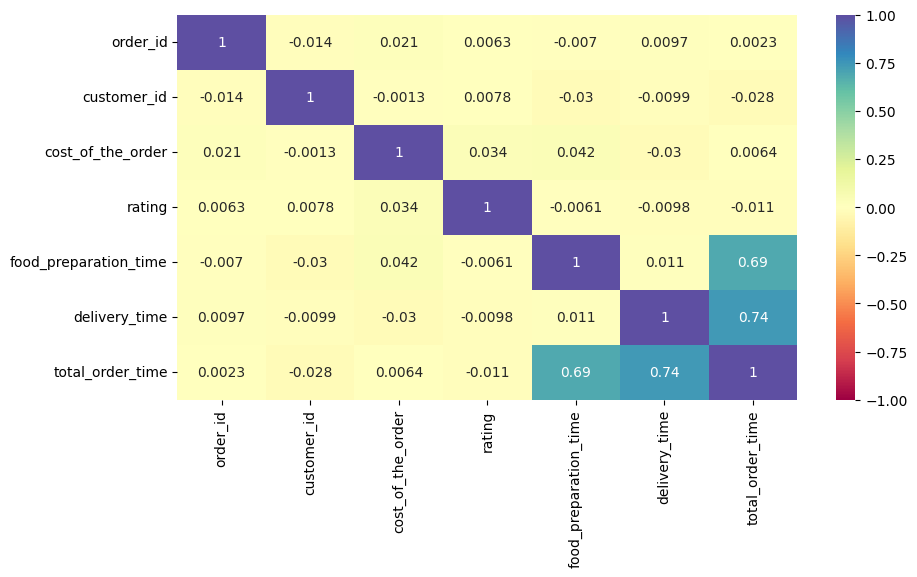

In [31]:
# Generating the correlation matrix to understand the correlation between the numerical columns in the data.
plt.figure(figsize=(10,5))
numeric_data = data.select_dtypes(include=["number"])
sns.heatmap(numeric_data.corr(),annot=True,cmap='Spectral',vmin=-1,vmax=1)
plt.show()

*   total_order_time, food_preparation_time, and delivery_time show a high correlation with each other which is expected.
*   cost_of_the_order and rating have high correlation.
*   Similarly, cost_of_the_order and food_preparation_time also have high correlation. Probably because bigger orders take longer to cook/prepare.
*   Whereas, cost_of_the_order and delivery_time has negative corelation. May be the delivery service people prioritise the delivery of high price orders more.
*   total_order_time and rating have a negative correlation, which makesense as the customer would have provided lower rating for orders taking long time.
*   customer_id and food_preparation_time has negative correlation.
*   customer_id and order_id also seem to have a negative correlation


---




**12.2. Observations on Correlation between rating and food_preparaton_time**

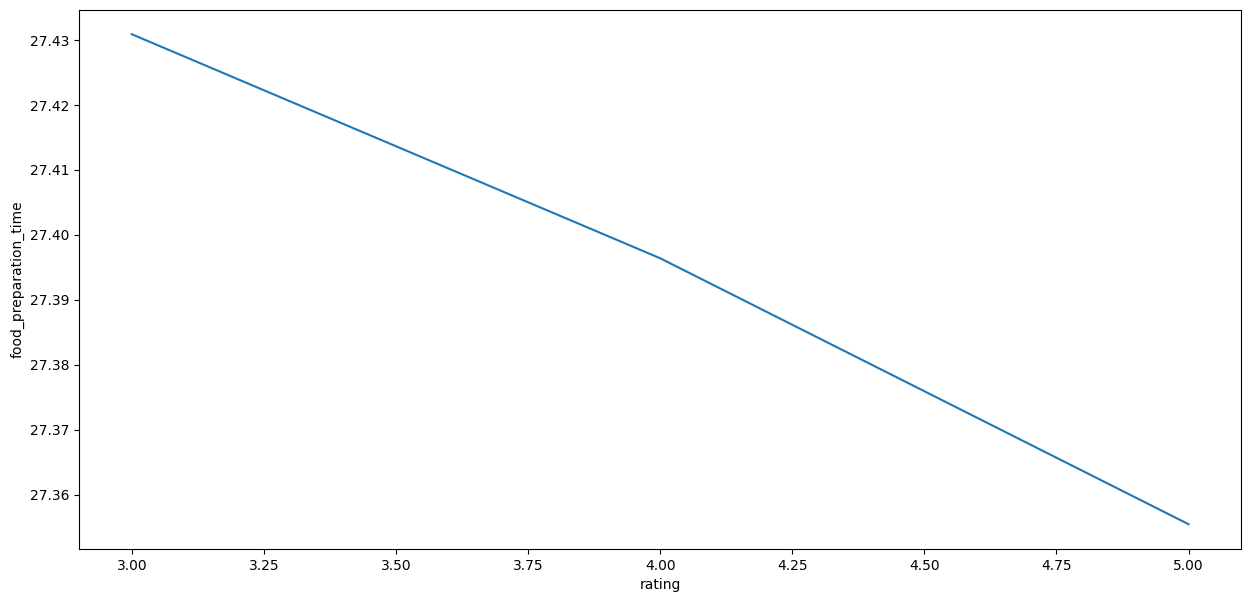

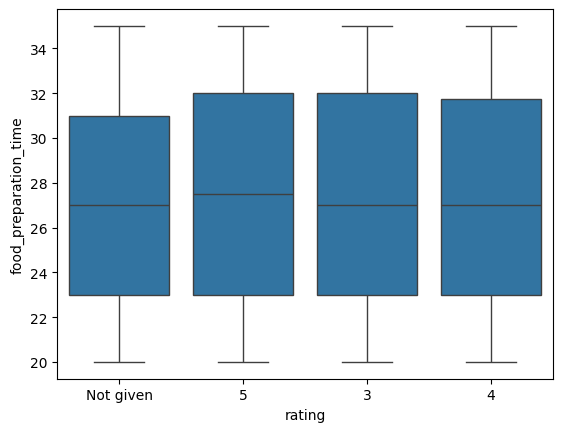

In [33]:
# Note: We are excluding the missing ratings from the below plot as its irrelevant.
plt.figure(figsize=(15,7))
sns.lineplot(data=data, x='rating', y ='food_preparation_time',errorbar=None)
plt.show()

# Note: We are including the missing ratings in the below plot as it helps in better understanding.
sns.boxplot(data=data_orig,x='rating',y='food_preparation_time')
plt.show()

*   As clearly shown in the line plot, lower the food preparation time higher the rating, and vice versa.

---

**12.3. Observations on Correlation between rating and cost_of_the_order**

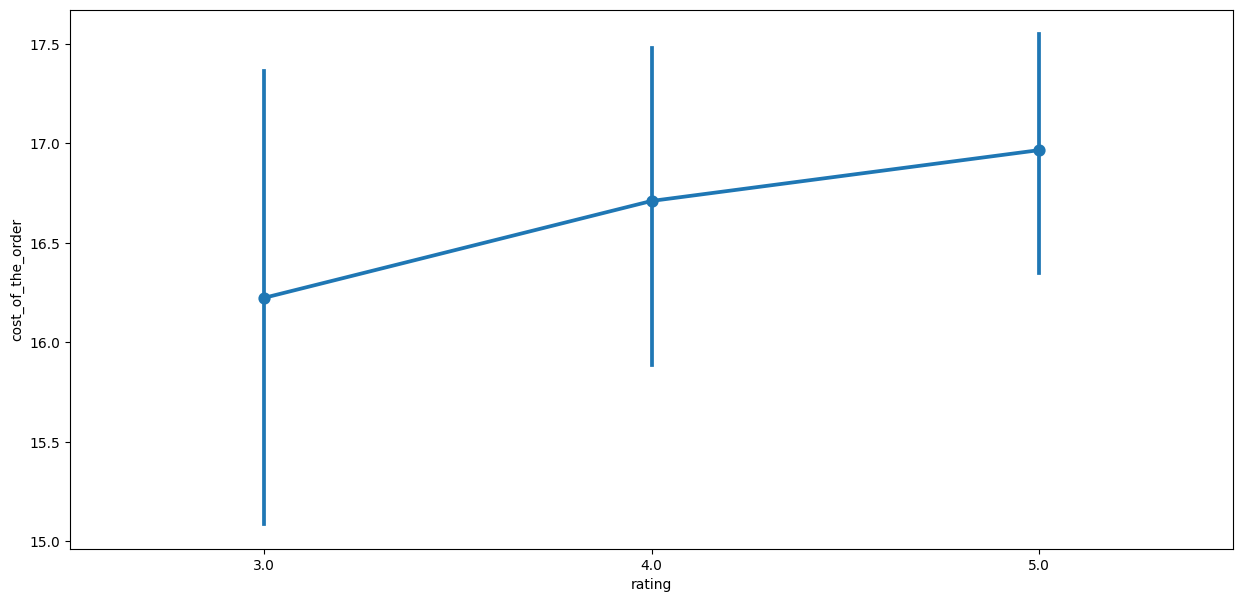

In [34]:
# Note: We are excluding the missing ratings from the below plot as its irrelevant.
plt.figure(figsize=(15, 7))
sns.pointplot(data=data, x='rating', y ='cost_of_the_order')
plt.show()


*   Ratings seem to be better for the orders with high cost.

---

**12.4. Observations on Correlation between rating and delivery_time**

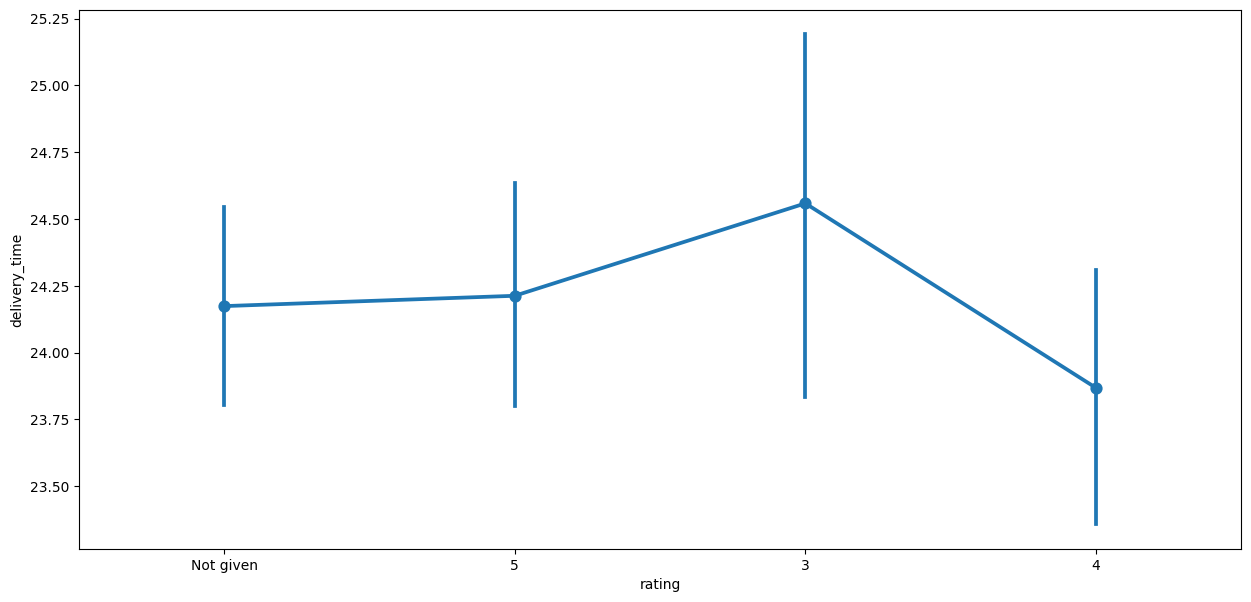

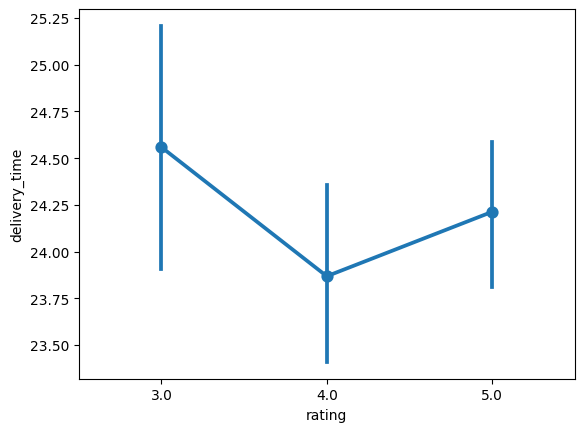

In [36]:
# Note: We are excluding the missing ratings from the below plot as its irrelevant.
plt.figure(figsize=(15, 7))
sns.pointplot(data=data_orig, x = 'rating', y = 'delivery_time')
plt.show()

sns.pointplot(data=data, x = 'rating', y = 'delivery_time')
plt.show()


*   It's fair to assume that, orders with higher delivery_time have lower rating.

---

**12.5. Observations on Correlation between Cuisine vs Cost of the order**

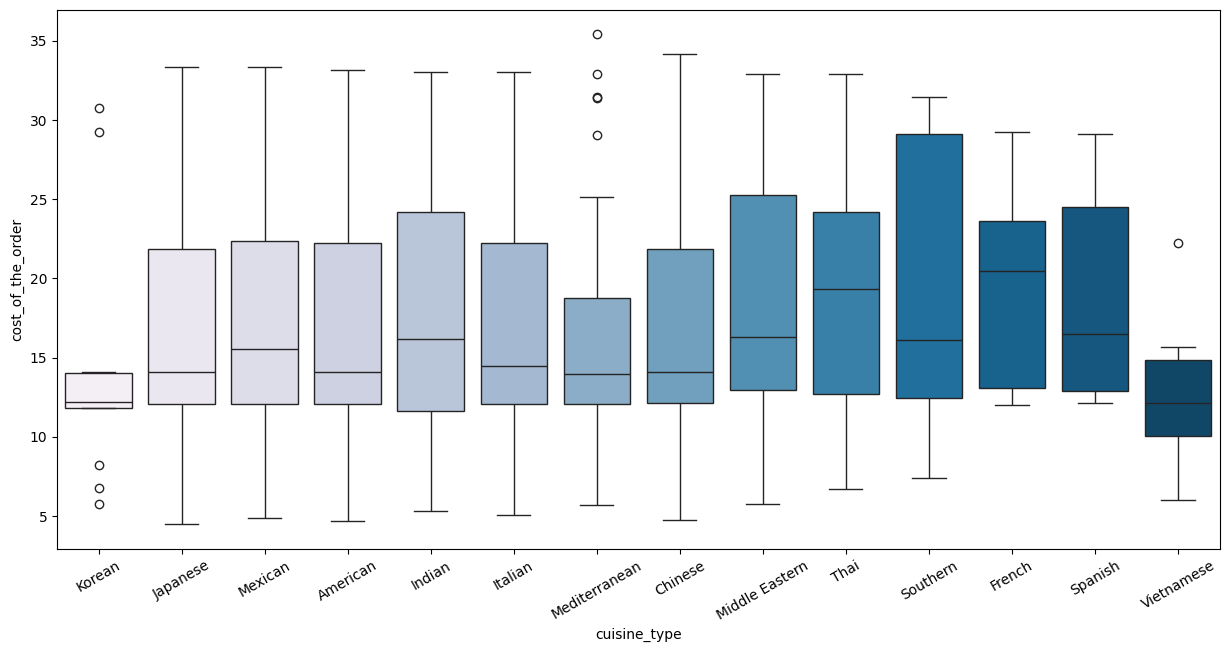

In [37]:
plt.figure(figsize=(15,7))
plt.xticks(rotation = 30)
sns.boxplot(data=data, x = "cuisine_type", y = "cost_of_the_order", palette = 'PuBu', hue = "cuisine_type")
plt.show()

*   Only Korean, Mediterranean and Vietnamese seem to have outliers.
*   Most expensive order is of type Mediterranean.
*   Least expensive order is of type Japanese.
*   French and Spanish cuisine orders are never less that $11


---

**12.6. Observations on Correlation between Cuisine vs Food Preparation time**

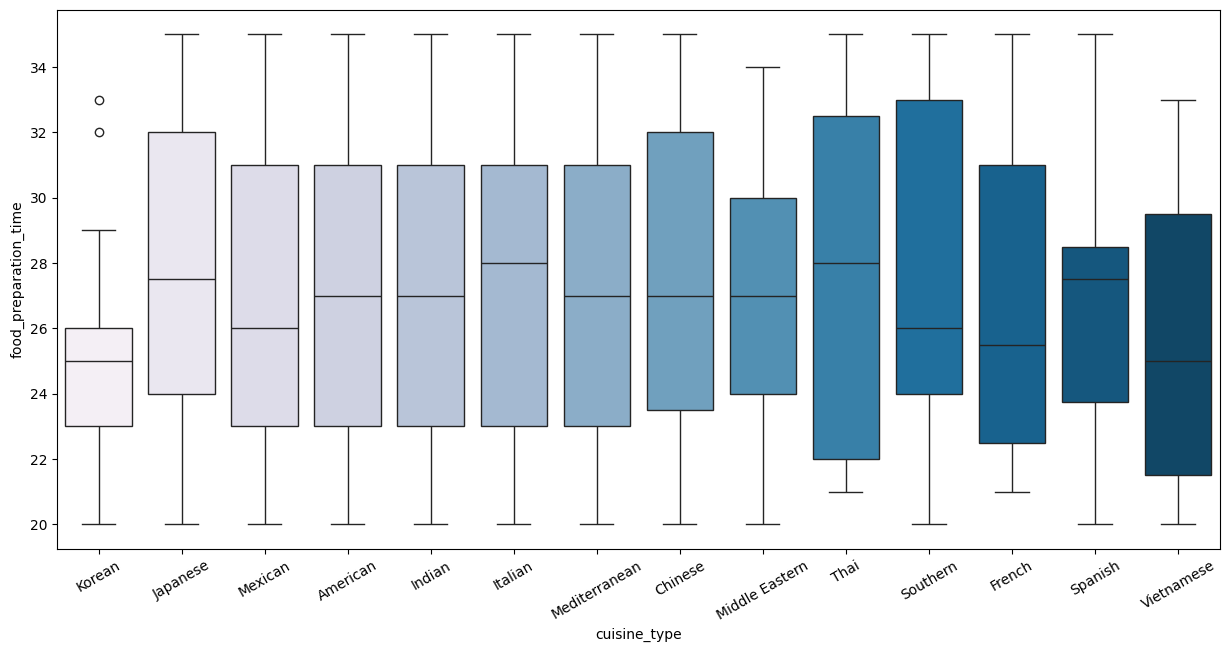

In [38]:
plt.figure(figsize=(15,7))
sns.boxplot(data=data, x = "cuisine_type", y = "food_preparation_time", palette = 'PuBu', hue = "cuisine_type")
plt.xticks(rotation = 30)
plt.show()

*   On average korean seem take least amount of time to prepare than rest
*   On average Italian, Thai, and Spanish cuisines take more time to prepare than rest


---

**12.7. Observations on Correlation between Day of the Week vs Delivery time**

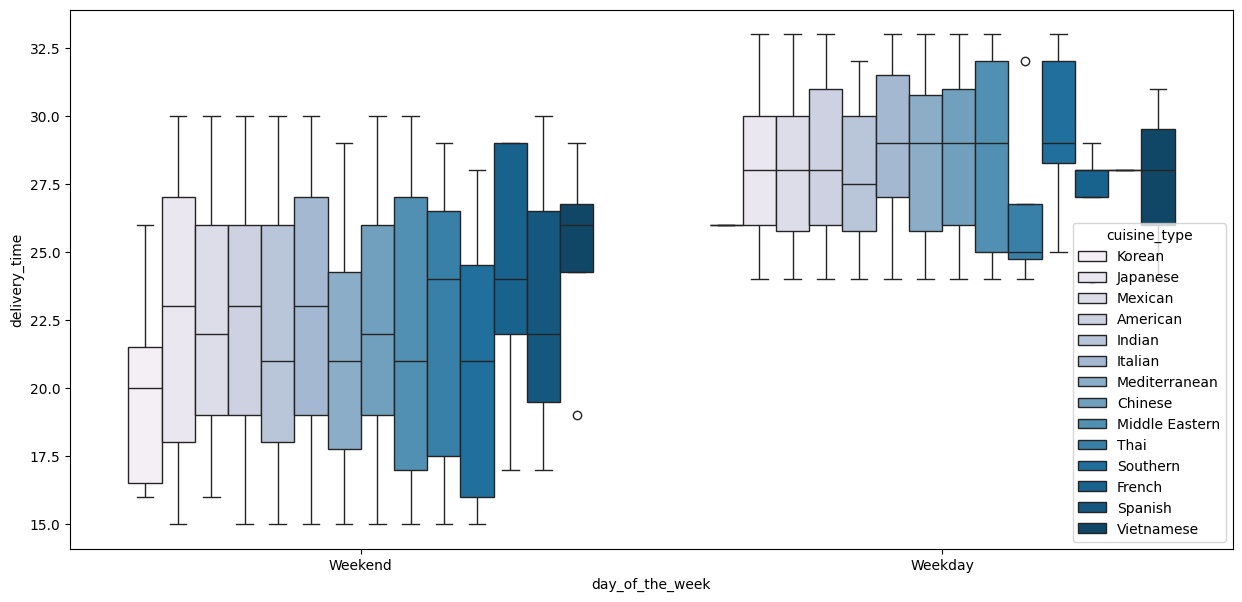

In [39]:
plt.figure(figsize=(15,7))
sns.boxplot(data=data, x = "day_of_the_week", y = "delivery_time", palette = 'PuBu', hue = "cuisine_type")
plt.show()

*   Delivery time of all cuisines is significantly more during weekdays than weekends.



---

**12.8. Observations on the revenues generated by each restaurant**

In [40]:
data.groupby(['restaurant_name'])['cost_of_the_order'].sum().sort_values(ascending = False).head(15)

restaurant_name
Shake Shack                      3579.53
The Meatball Shop                2145.21
Blue Ribbon Sushi                1903.95
Blue Ribbon Fried Chicken        1662.29
Parm                             1112.76
RedFarm Broadway                  965.13
RedFarm Hudson                    921.21
TAO                               834.50
Han Dynasty                       755.29
Blue Ribbon Sushi Bar & Grill     666.62
Rubirosa                          660.45
Sushi of Gari 46                  640.87
Nobu Next Door                    623.67
Five Guys Burgers and Fries       506.47
Momoya                            492.13
Name: cost_of_the_order, dtype: float64

*   Shake Shack seem to be the most popular restaurant generating highest revenue followed by 'The Meatball Shop'   



---

### **Question 13:** The company wants to provide a promotional offer in the advertisement of the restaurants. The condition to get the offer is that the restaurants must have a rating count of more than 50 and the average rating should be greater than 4. Find the restaurants fulfilling the criteria to get the promotional offer. [3 marks]

In [41]:
# Restaurants with more than 50 ratings and the average rating is greater than 4
(data.groupby('restaurant_name').rating.agg(['count', 'mean'])).query('count > 50 and mean > 4').sort_values(by = 'mean', ascending = False)

,count,mean
restaurant_name,,
The Meatball Shop,84,4.511905
Blue Ribbon Fried Chicken,64,4.328125
Shake Shack,133,4.278195
Blue Ribbon Sushi,73,4.219178


#### Observations:
Following are the restaurants with more than 50 ratings and the average rating is greater than 4:

*   The Meatball Shop
*   Blue Ribbon Fried Chicken
*   Shake Shack
*   Blue Ribbon Sushi





### **Question 14:** The company charges the restaurant 25% on the orders having cost greater than 20 dollars and 15% on the orders having cost greater than 5 dollars. Find the net revenue generated by the company across all orders. [3 marks]

In [42]:
# Total net revenue of the company
for order in range(len(data)):
  cost = data.loc[order,'cost_of_the_order']
  if cost>20:
    rev = cost*(25/100)
  elif cost>5:
    rev = cost*(15/100)
  else:
    rev = 0
  data.loc[order,'net_revenue'] = rev
data['net_revenue'].sum()


6166.303

#### Observations:
The net revenue generated by the company is: $6166.303

### **Question 15:** The company wants to analyze the total time required to deliver the food. What percentage of orders take more than 60 minutes to get delivered from the time the order is placed? (The food has to be prepared and then delivered.) [2 marks]

In [43]:
# Percentage of orders with total order time more than 60 minutes
(data[(data['food_preparation_time'] + data['delivery_time']) > 60].shape[0] / data.shape[0]) * 100


10.537407797681771

#### Observations:
About 10.54% of the total orders take more than 60 minutes of time for the food preparation & delivery combined.

### **Question 16:** The company wants to analyze the delivery time of the orders on weekdays and weekends. How does the mean delivery time vary during weekdays and weekends? [2 marks]

In [44]:
# Variation of mean delivery_time on weekdays and weekends.
data.groupby('day_of_the_week').delivery_time.agg(['mean', 'count'])

,mean,count
day_of_the_week,,
Weekday,28.340037,547
Weekend,22.470022,1351


#### Observations:
There is not much difference in the delivery_time of the orders on weekdays vs. weekends. Infact, though the number of orders on weekends is more, the average delivery_time is slightly lesser than that of the weekdays. This probably could be because of less traffic on weekends and also more availability of delivery service people.

### Conclusion and Recommendations

### **Question 17:** What are your conclusions from the analysis? What recommendations would you like to share to help improve the business? (You can use cuisine type and feedback ratings to drive your business recommendations.) [6 marks]

### Conclusions:

The food aggregator company connects 1200 customers with 178 restaurants offering 14 different types of cuisines. The most popular and highest revenue-generating restaurants are Shake Shack and The Meatball Shop, both of which are also highly rated.

Customers tend to order more on weekends, with American, Japanese, Italian, and Chinese being the top ordered cuisines. The average cost per order is 14 dollars, with 70 percent of orders costing under 20 dollars and the highest order costing 35 dollars. Mediterranean cuisine is the most expensive, while Japanese is the least expensive.

Delivery takes an average of 52 minutes, with 28 minutes for food preparation and 24 minutes for delivery. About 10 percent of orders exceed 60 minutes. Korean cuisine has the shortest preparation time, whereas Italian, Thai, and Spanish cuisines take the longest.

Customer satisfaction is high, with over 75% of ratings being 4 or above out of 5. However, high preparation and delivery times tend to result in lower ratings. The company's total net revenue to date is 6166 dollars.


---





### Recommendations:

Based on the provided data, here are some recommendations for the food aggregator company:

**Optimize Delivery and Preparation Times:**

*   Focus on Efficiency: Provide feedback to restaurants to streamline kitchen processes or hiring additional staff during peak hours, particularly for Italian, Thai, and Spanish cuisines, which take the longest to prepare.
*   Improve Delivery Logistics: Implement better routing algorithms or partner with more delivery personnel to reduce delivery times. This will help in decreasing the overall time it takes for orders to reach customers, especially the 10% of orders taking more than 60 minutes.

**Enhance Customer Experience:**

*   Address Long Wait Times: Given that orders with high preparation and delivery times receive lower ratings, consider offering discounts or incentives for these delayed orders to improve customer satisfaction.
*   Real-Time Updates: Provide customers with real-time updates on their order status to manage expectations better.

**Pricing Strategies:**

*   Flexible Pricing: Introduce special pricing for weekends when order volumes are higher to maximize revenue.
*   Value Deals: Offer combo deals or discounts for orders above a certain amount to encourage higher spending per order.
*   Incentivise new customers with discounts.
*   Loyalty Programs: Implement a loyalty program to reward repeat customers and encourage them to provide feedback.

**Promote High-Demand Cuisines:**

*   Marketing Campaigns: Leverage the popularity of American, Japanese, Italian, and Chinese cuisines through targeted marketing campaigns and promotions to drive more orders in these categories.




---